# Evaluation - GenAI Multi-Agent Recruiting Chatbot

Runs the full multi-agent system over the labeled conversations (`sms_conversations.json`) and compares the Main Agent's predicted action (**Continue / Schedule / End**) against the label at each recruiter turn.

Metrics reported: **Accuracy**, **Confusion Matrix**, a per-class precision/recall/F1 report, and a short error analysis.

> Note: this notebook makes live OpenAI API calls (one Main Agent turn per labeled example), so it needs `OPENAI_API_KEY` in `.env` and takes a few minutes to run top to bottom.

## 1. Setup

In [1]:
import sys, os
# Make the project root importable when running from tests/.
sys.path.insert(0, os.path.abspath('..'))

import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

from app.modules import evaluation

load_dotenv('../.env')
assert os.getenv('OPENAI_API_KEY'), 'Set OPENAI_API_KEY in .env before running.'
print('Setup ready.')

Setup ready.


## 2. Build the labeled evaluation set

Every recruiter turn that carries a label and has a preceding candidate message. Opening turns (no history) are excluded.

In [2]:
examples = evaluation.build_eval_examples()
print(f'{len(examples)} labeled turns')

from collections import Counter
print('label distribution:', dict(Counter(e['label'] for e in examples)))

44 labeled turns
label distribution: {'schedule': 19, 'end': 15, 'continue': 10}


## 3. Run the system (predict an action per turn)

Each example runs one full Main Agent turn: route to an advisor, consume its output, and decide Continue / Schedule / End.

In [3]:
y_true = [e['label'] for e in examples]
y_pred = evaluation.predict_actions(examples, progress=True)
print('\nDone.')

[ 1/44] conv 1 turn 3  label=schedule  pred=schedule


[ 2/44] conv 1 turn 5  label=schedule  pred=continue


[ 3/44] conv 1 turn 7  label=end       pred=end


[ 4/44] conv 2 turn 3  label=continue  pred=schedule


[ 5/44] conv 2 turn 5  label=continue  pred=continue


...

[40/44] conv14 turn 3  label=schedule  pred=schedule


[41/44] conv14 turn 5  label=schedule  pred=continue


[42/44] conv14 turn 7  label=end       pred=continue


[43/44] conv15 turn 3  label=schedule  pred=schedule


[44/44] conv15 turn 5  label=end       pred=end

Done.


## 4. Accuracy and per-class report

In [4]:
metrics = evaluation.compute_metrics(y_true, y_pred)
print(f"Accuracy: {metrics['accuracy']:.3f}\n")
print(metrics['report'])

Accuracy: 0.682

              precision    recall  f1-score   support

    continue       0.36      0.40      0.38        10
    schedule       0.68      0.68      0.68        19
         end       0.93      0.87      0.90        15

    accuracy                           0.68        44
   macro avg       0.66      0.65      0.65        44
weighted avg       0.69      0.68      0.69        44



## 5. Confusion matrix

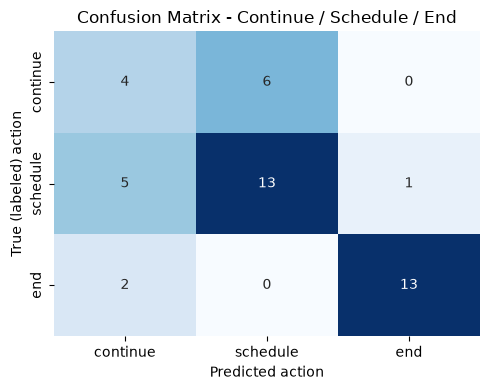

In [5]:
cm = metrics['confusion_matrix']
labels = metrics['labels']

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, cbar=False, ax=ax)
ax.set_xlabel('Predicted action')
ax.set_ylabel('True (labeled) action')
ax.set_title('Confusion Matrix - Continue / Schedule / End')
plt.tight_layout()
plt.show()

## 6. Error analysis

The turns where the predicted action disagreed with the label.

In [6]:
errors = evaluation.find_errors(examples, y_true, y_pred)
print(f'{len(errors)} misclassified turns of {len(examples)}\n')
for e in errors:
    print(f"conv{e['conversation_id']} turn{e['turn_id']}: "
          f"true={e['actual']} pred={e['predicted']}")
    print(f"   last candidate msg: {e['last_candidate_msg']!r}\n")

14 misclassified turns of 44

conv1 turn5: true=schedule pred=continue
   last candidate msg: "I can't at that time—I'm busy."

conv2 turn3: true=continue pred=schedule
   last candidate msg: "I have three years' experience with Django and Flask."

conv3 turn3: true=continue pred=schedule
   last candidate msg: 'Sure, I have four years of Python experience and two with SQL.'

conv4 turn3: true=continue pred=schedule
   last candidate msg: "I've been using Python professionally for five years, mostly for data analysis."

conv8 turn5: true=schedule pred=continue
   last candidate msg: "Those slots don't work for me."

conv8 turn7: true=schedule pred=end
   last candidate msg: "I'm unavailable at that time, as I have other commitments. I'll reach out if it becomes relevant"

conv10 turn3: true=continue pred=schedule
   last candidate msg: "I've been using Python for a couple of month, I don't have much experience in that area, but I'm eager to learn and quickly adapt."

conv10 turn5: true

## 7. Summary

On the 44 labeled recruiter turns the Main Agent reproduces the **Continue / Schedule / End** decisions with an accuracy of about **0.68**.

- **End** is detected reliably (recall ~0.87): the system recognizes when a candidate commits to a time or declines.
- **Schedule** is recovered well (recall ~0.68) after making the agent proactive about proposing interview times, which is the bot's goal.
- The remaining errors sit almost entirely on the **Continue vs Schedule** boundary: after a candidate answers a question, the recruiter may either ask another question (Continue) or propose an interview (Schedule). The labels themselves are split on near-identical inputs (for example conv 1 turn 3 is labeled Schedule while conv 4 turn 3, a nearly identical answer, is labeled Continue), so this boundary is inherently noisy.

The bot is deliberately biased toward scheduling, which favors its objective of booking interviews.